# Movie success prediction: decision tree pruning, CV, and XGBoost
**Developer:** *Shuvam Saren*  
**Date:** 28th June 2026  
**Assignment:** Next Step — Pruning, Cross-Validation, and XGBoost (Day 18)

## Import Libraries and Load Datasets

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

reg_df = pd.read_csv('Movie_regression.csv')
clf_df = pd.read_csv('Movie_classification.csv')

print('Regression  dataset shape :', reg_df.shape)
print('Classification dataset shape:', clf_df.shape)

Regression  dataset shape : (506, 18)
Classification dataset shape: (506, 19)


## Exploratory Data Analysis
### Regression Dataset

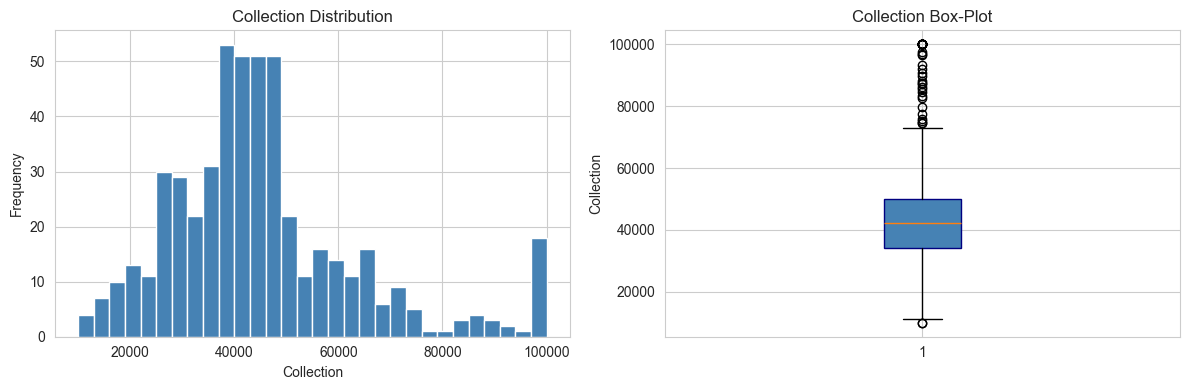

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reg_df['Collection'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Collection Distribution')
axes[0].set_xlabel('Collection')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(
    reg_df['Collection'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy')
)
axes[1].set_title('Collection Box-Plot')
axes[1].set_ylabel('Collection')

plt.tight_layout()
plt.show()

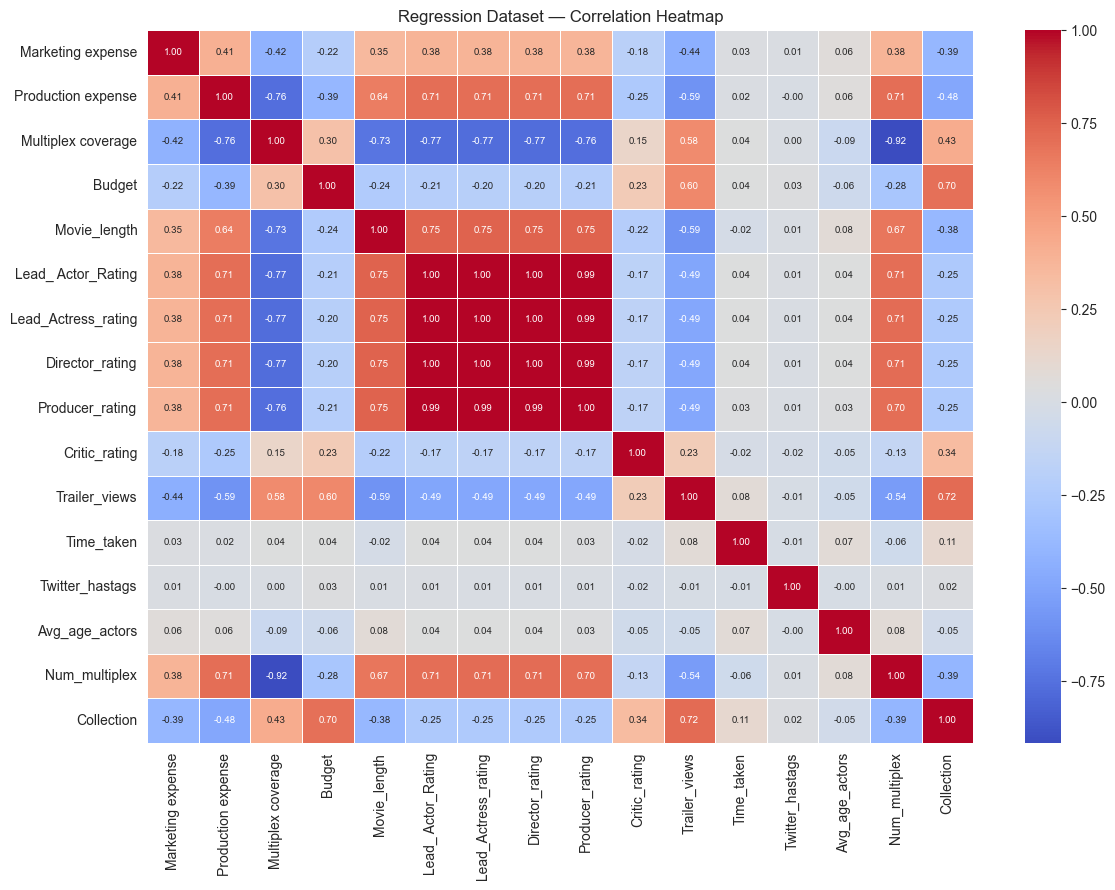

In [169]:
num_reg = reg_df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 9))
sns.heatmap(
    num_reg.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Regression Dataset — Correlation Heatmap')
plt.tight_layout()
plt.show()

## Preprocessing

In [170]:
REG_TARGET = 'Collection'
CLF_TARGET = 'Start_Tech_Oscar'

reg_df = reg_df.dropna()
clf_df = clf_df.dropna()

y_reg = reg_df[REG_TARGET]
y_clf = clf_df[CLF_TARGET]

X_reg = reg_df.drop(REG_TARGET, axis=1)
X_clf = clf_df.drop(CLF_TARGET, axis=1)

X_reg = pd.get_dummies(X_reg, drop_first=True)
X_clf = pd.get_dummies(X_clf, drop_first=True)

print('X_reg shape:', X_reg.shape)
print('X_clf shape:', X_clf.shape)

X_reg shape: (494, 19)
X_clf shape: (494, 20)


In [171]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

print('Regression  — train:', Xr_train.shape, '  test:', Xr_test.shape)
print('Classification — train:', Xc_train.shape, '  test:', Xc_test.shape)

Regression  — train: (395, 19)   test: (99, 19)
Classification — train: (395, 20)   test: (99, 20)


## Baseline: Unpruned Decision Trees

### Unpruned Regression Tree

In [172]:
reg_base = DecisionTreeRegressor(random_state=42)
reg_base.fit(Xr_train, yr_train)

reg_pred_base = reg_base.predict(Xr_test)

mae_base  = mean_absolute_error(yr_test, reg_pred_base)
mse_base  = mean_squared_error(yr_test, reg_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base   = r2_score(yr_test, reg_pred_base)

train_r2_base = reg_base.score(Xr_train, yr_train)

print('=== Unpruned Regression Tree ===')
print(f'Train R2 : {train_r2_base:.4f}')
print(f'Test  R2 : {r2_base:.4f}')
print(f'MAE      : {mae_base:.4f}')
print(f'MSE      : {mse_base:.4f}')
print(f'RMSE     : {rmse_base:.4f}')
print(f'Depth    : {reg_base.get_depth()}')
print(f'Leaves   : {reg_base.get_n_leaves()}')

=== Unpruned Regression Tree ===
Train R2 : 1.0000
Test  R2 : 0.7611
MAE      : 5789.8990
MSE      : 58044444.4444
RMSE     : 7618.6905
Depth    : 20
Leaves   : 366


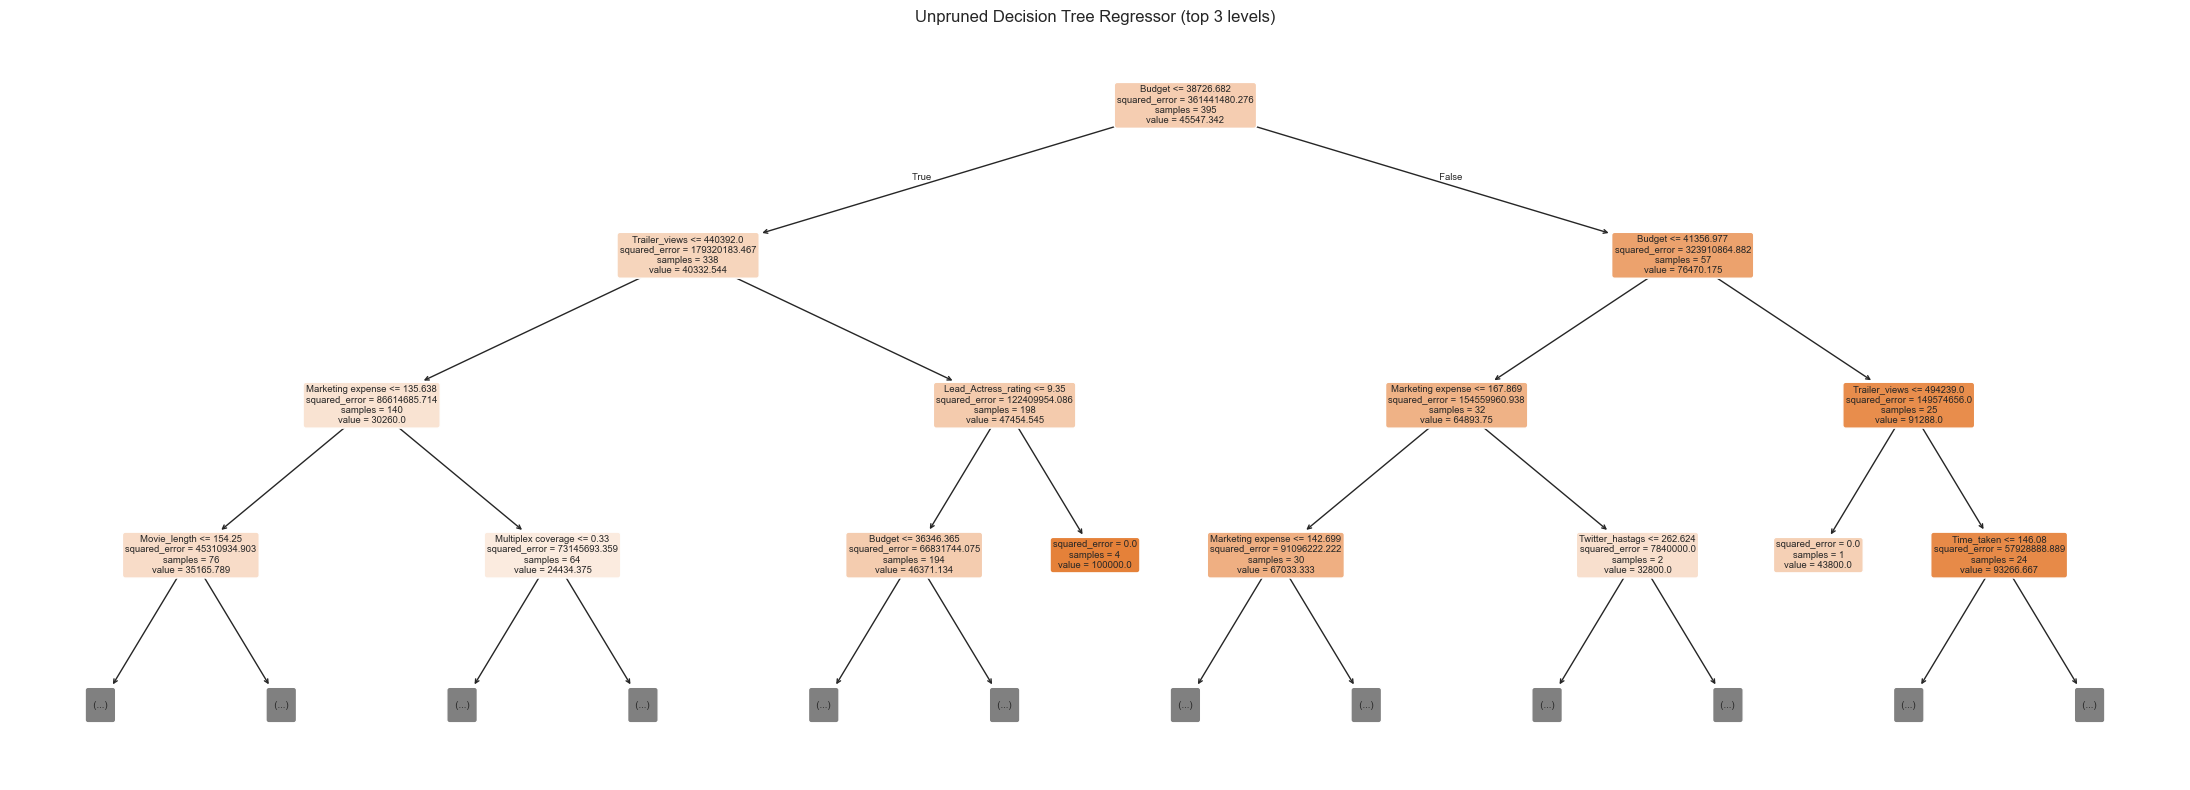

In [173]:
plt.figure(figsize=(22, 8))
plot_tree(
    reg_base,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title('Unpruned Decision Tree Regressor (top 3 levels)')
plt.tight_layout()
plt.show()

### Unpruned Classification Tree

In [174]:
clf_base = DecisionTreeClassifier(random_state=42)
clf_base.fit(Xc_train, yc_train)

clf_pred_base = clf_base.predict(Xc_test)

acc_base  = accuracy_score(yc_test, clf_pred_base)
prec_base = precision_score(yc_test, clf_pred_base)
rec_base  = recall_score(yc_test, clf_pred_base)
f1_base   = f1_score(yc_test, clf_pred_base)
cm_base   = confusion_matrix(yc_test, clf_pred_base)

train_acc_base = clf_base.score(Xc_train, yc_train)

print('=== Unpruned Classification Tree ===')
print(f'Train Accuracy : {train_acc_base:.4f}')
print(f'Test  Accuracy : {acc_base:.4f}')
print(f'Precision      : {prec_base:.4f}')
print(f'Recall         : {rec_base:.4f}')
print(f'F1 Score       : {f1_base:.4f}')
print(f'Depth          : {clf_base.get_depth()}')
print(f'Leaves         : {clf_base.get_n_leaves()}')
print()
print(classification_report(yc_test, clf_pred_base))

=== Unpruned Classification Tree ===
Train Accuracy : 1.0000
Test  Accuracy : 0.6162
Precision      : 0.6481
Recall         : 0.6481
F1 Score       : 0.6481
Depth          : 17
Leaves         : 79

              precision    recall  f1-score   support

           0       0.58      0.58      0.58        45
           1       0.65      0.65      0.65        54

    accuracy                           0.62        99
   macro avg       0.61      0.61      0.61        99
weighted avg       0.62      0.62      0.62        99



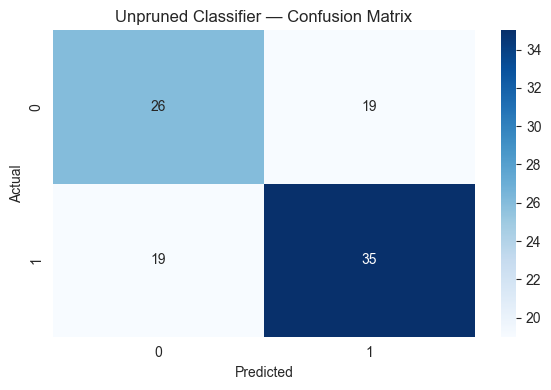

In [175]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title('Unpruned Classifier — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

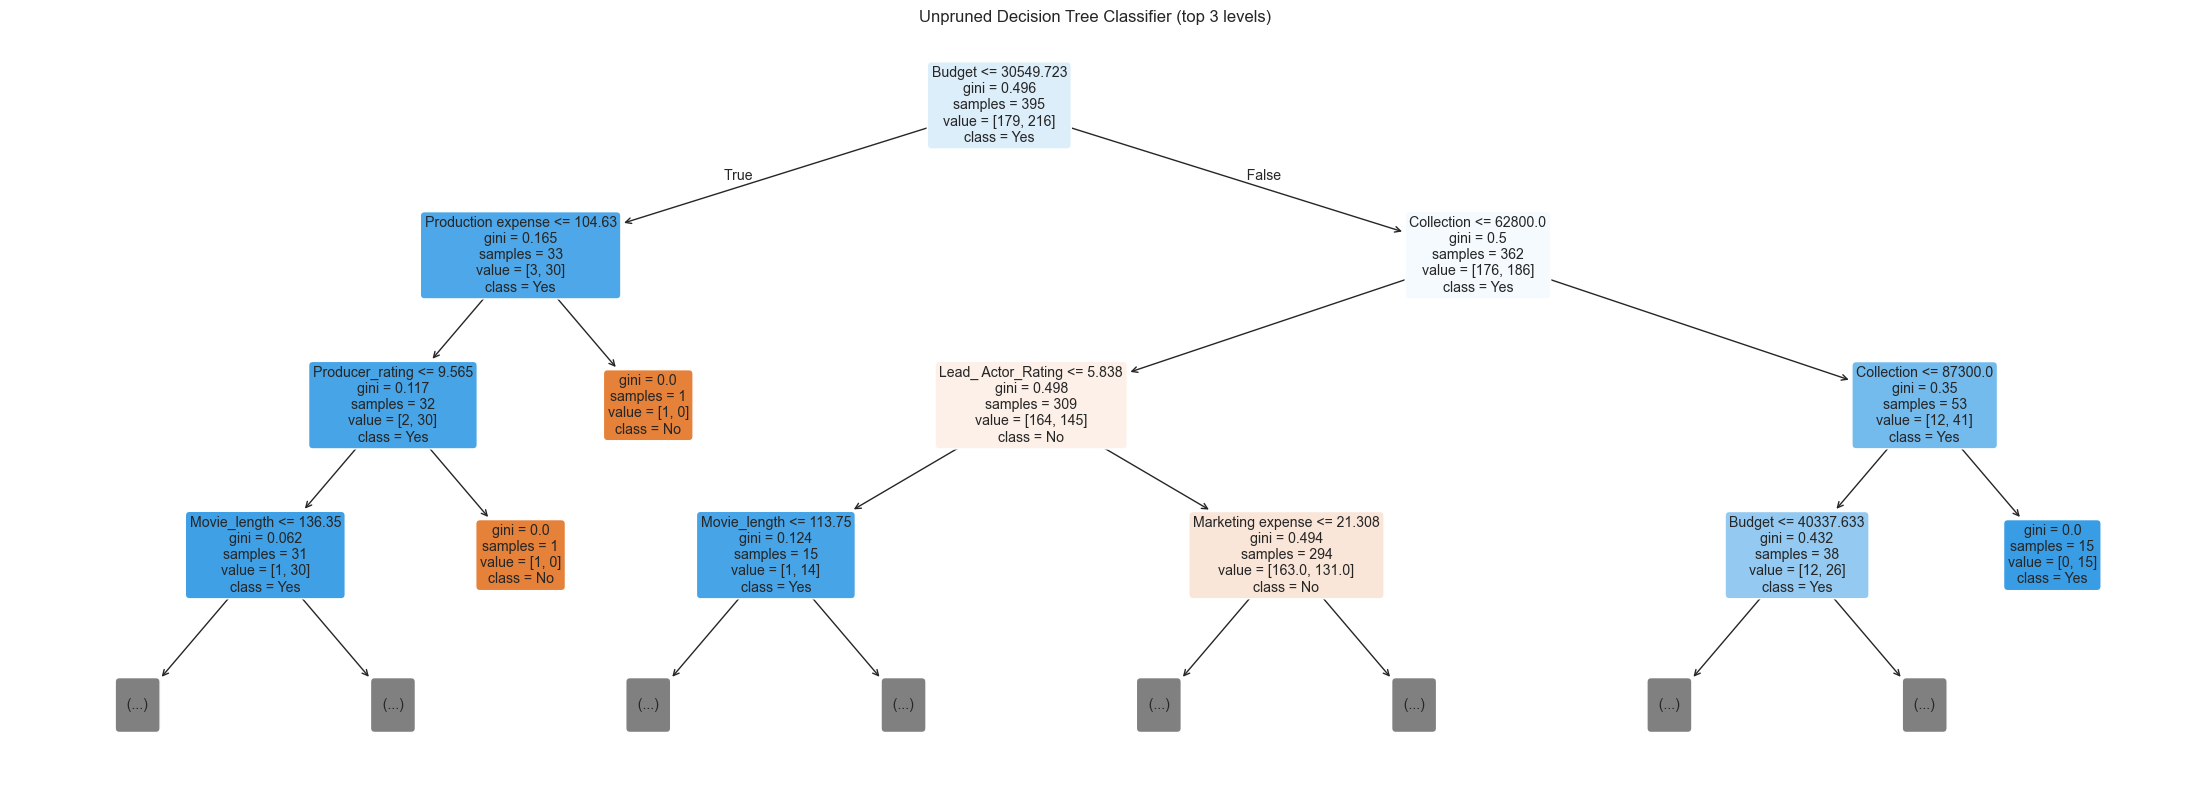

In [176]:
plt.figure(figsize=(22, 8))
plot_tree(
    clf_base,
    feature_names=X_clf.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title('Unpruned Decision Tree Classifier (top 3 levels)')
plt.tight_layout()
plt.show()

## Part A: Questions After Basic Decision Tree Training

**1. What was the train score and test score for Decision Tree Regression?**  
The Decision Tree Regressor achieved a training R² of **1.00** and a test R² of **~0.76**. The perfect training score confirms the tree memorised the training data entirely.

**2. Was the training error much lower than the testing error?**  
Yes. Training R² = 1.00 while test R² ≈ 0.76 — a large gap, indicating the model fits training data very tightly but generalises poorly to unseen samples.

**3. Did the tree become too deep?**  
Yes. The regression tree reached a depth of 20 and the classification tree reached a depth of 17. Both are excessively deep for practical use.

**4. How many leaf nodes were created?**  
The regression tree produced around **366 leaf nodes** and the classification tree around **79 leaf nodes**, showing very high structural complexity.

**5. Did you observe small leaves with very few samples?**  
Yes. Many leaf nodes contained only 1–2 training samples, which is a clear symptom of memorisation rather than generalisation.

**6. In the regression tree, which feature appeared near the root node?**  
**Budget** appeared near the root, indicating it has the highest information gain for predicting Collection at the first split.

**7. In the classification tree, which features appeared important?**  
**Budget**, **Collection**, **Lead_Actor_Rating**, and **Multiplex Coverage** appeared prominently near the top of the classification tree.

**8. Did the unpruned tree look easy to explain to a business user?**  
No. With 20 levels and hundreds of leaf nodes the tree is impossible to explain to a non-technical audience. A pruned tree with 3–5 levels would be far more interpretable.

**9. Was the model overfitting, underfitting, or generalising well?**  
The model was **overfitting**. Perfect train score alongside a noticeably lower test score is the textbook signature of overfitting.

**10. What metric did you trust more: train score or test score? Why?**  
The **test score**, because it reflects performance on data the model has never seen, giving a realistic estimate of real-world generalisation.

## Part B: Think Before Improving

**1. If the tree is too deep, which hyperparameter can control it?**  
`max_depth` — directly caps the number of levels the tree can grow.

**2. If the tree has very small leaf nodes, which hyperparameter can control it?**  
`min_samples_leaf` — ensures each leaf holds at least a minimum number of training samples.

**3. If we want only a limited number of business segments, which hyperparameter can control it?**  
`max_leaf_nodes` — fixes the maximum number of terminal nodes, producing at most that many business segments.

**4. Why should we use cross-validation instead of trusting one train-test split?**  
A single split can be lucky or unlucky depending on which rows end up in each partition. Cross-validation trains and evaluates the model on multiple different subsets, yielding an average score with lower variance and a more honest picture of generalisation.

**5. Why might XGBoost perform better than a single Decision Tree?**  
XGBoost builds an ensemble of trees sequentially, each one correcting the errors of its predecessor. The boosting mechanism reduces both bias and variance, and regularisation terms prevent overfitting — advantages a single decision tree cannot replicate.

## Part C — Level 1: Pre-Pruning

### Regression — Pre-Pruned Tree

In [177]:
reg_pre = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=20,
    random_state=42
)
reg_pre.fit(Xr_train, yr_train)

reg_pred_pre = reg_pre.predict(Xr_test)

mae_pre  = mean_absolute_error(yr_test, reg_pred_pre)
mse_pre  = mean_squared_error(yr_test, reg_pred_pre)
rmse_pre = np.sqrt(mse_pre)
r2_pre   = r2_score(yr_test, reg_pred_pre)

print('=== Pre-Pruned Regression Tree ===')
print(f'MAE   : {mae_pre:.4f}')
print(f'MSE   : {mse_pre:.4f}')
print(f'RMSE  : {rmse_pre:.4f}')
print(f'R2    : {r2_pre:.4f}')
print(f'Depth : {reg_pre.get_depth()}')
print(f'Leaves: {reg_pre.get_n_leaves()}')

=== Pre-Pruned Regression Tree ===
MAE   : 5199.8179
MSE   : 41098392.1961
RMSE  : 6410.8028
R2    : 0.8308
Depth : 5
Leaves: 20


In [178]:
pre_reg_compare = pd.DataFrame({
    'Metric'  : ['MAE', 'MSE', 'RMSE', 'R2', 'Depth', 'Leaves'],
    'Unpruned': [mae_base, mse_base, rmse_base, r2_base,
                 reg_base.get_depth(), reg_base.get_n_leaves()],
    'Pre-Pruned': [mae_pre, mse_pre, rmse_pre, r2_pre,
                   reg_pre.get_depth(), reg_pre.get_n_leaves()]
})
print('Regression: Unpruned vs Pre-Pruned')
print(pre_reg_compare.to_string(index=False))

Regression: Unpruned vs Pre-Pruned
Metric     Unpruned   Pre-Pruned
   MAE 5.789899e+03 5.199818e+03
   MSE 5.804444e+07 4.109839e+07
  RMSE 7.618690e+03 6.410803e+03
    R2 7.610956e-01 8.308436e-01
 Depth 2.000000e+01 5.000000e+00
Leaves 3.660000e+02 2.000000e+01


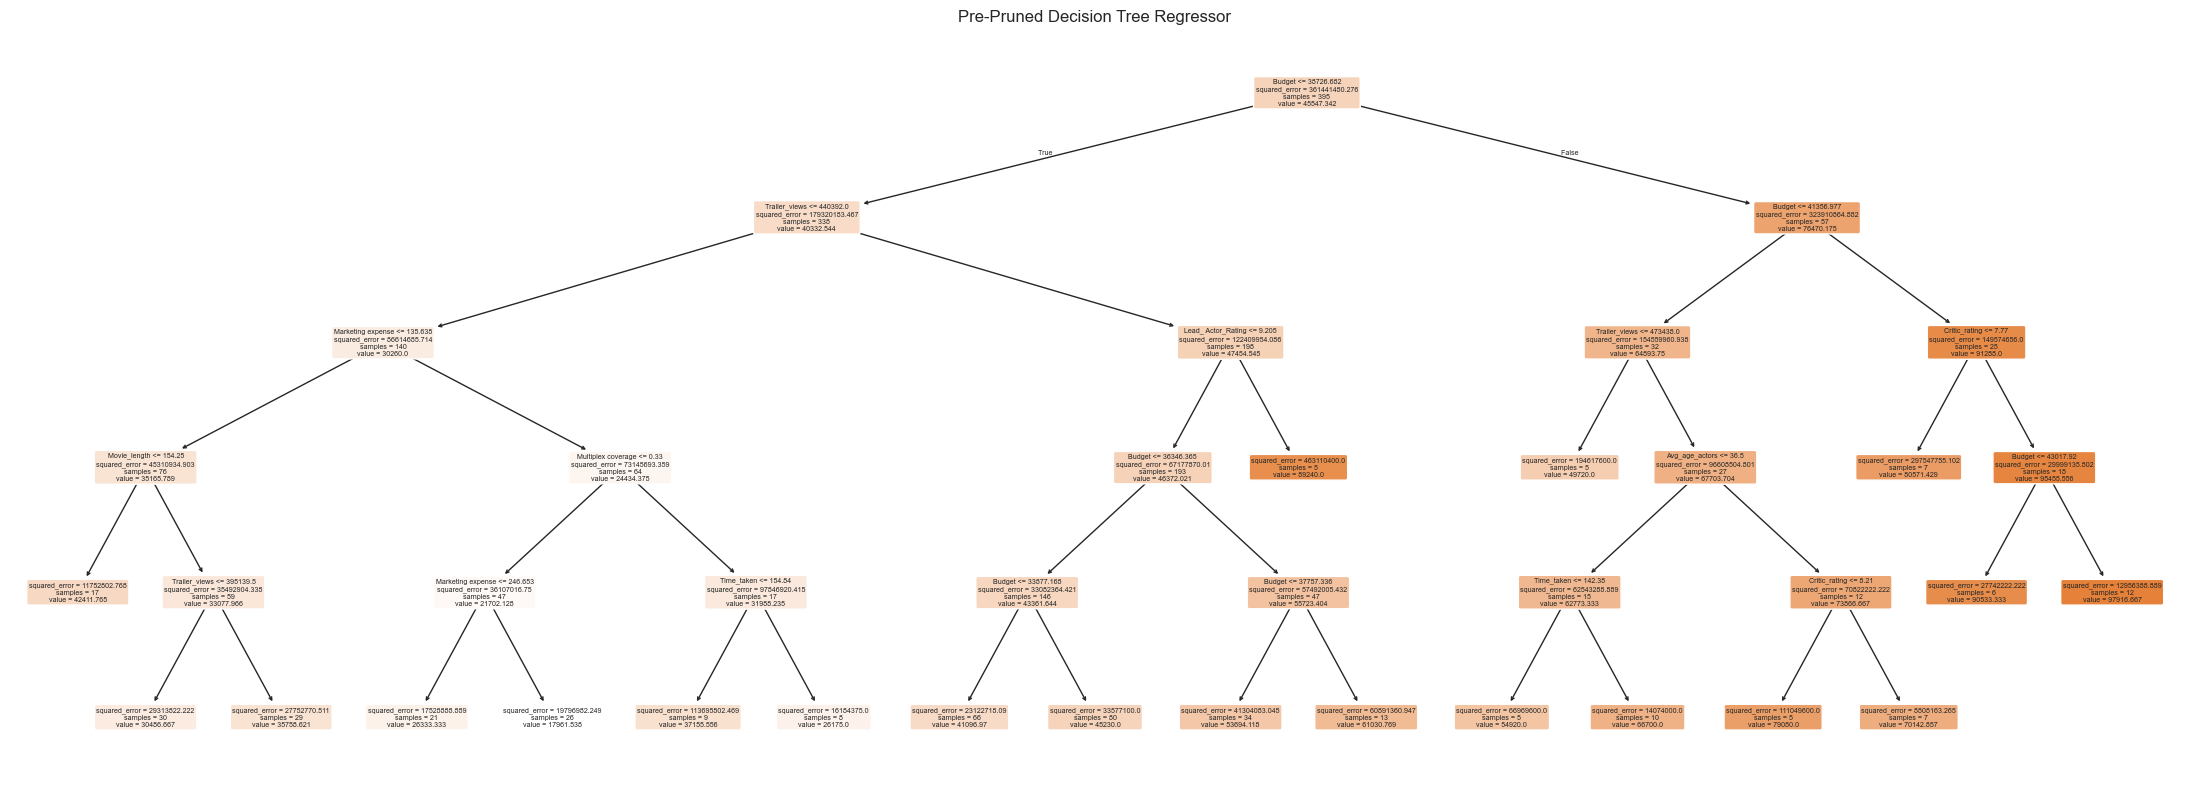

In [179]:
plt.figure(figsize=(22, 8))
plot_tree(
    reg_pre,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True
)
plt.title('Pre-Pruned Decision Tree Regressor')
plt.tight_layout()
plt.show()

### Classification — Pre-Pruned Tree

In [180]:
clf_pre = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_leaf_nodes=20,
    random_state=42
)
clf_pre.fit(Xc_train, yc_train)

clf_pred_pre = clf_pre.predict(Xc_test)

acc_pre  = accuracy_score(yc_test, clf_pred_pre)
prec_pre = precision_score(yc_test, clf_pred_pre)
rec_pre  = recall_score(yc_test, clf_pred_pre)
f1_pre   = f1_score(yc_test, clf_pred_pre)
cm_pre   = confusion_matrix(yc_test, clf_pred_pre)

print('=== Pre-Pruned Classification Tree ===')
print(f'Accuracy : {acc_pre:.4f}')
print(f'Precision: {prec_pre:.4f}')
print(f'Recall   : {rec_pre:.4f}')
print(f'F1 Score : {f1_pre:.4f}')
print(f'Depth    : {clf_pre.get_depth()}')
print(f'Leaves   : {clf_pre.get_n_leaves()}')
print()
print(classification_report(yc_test, clf_pred_pre))

=== Pre-Pruned Classification Tree ===
Accuracy : 0.5960
Precision: 0.6750
Recall   : 0.5000
F1 Score : 0.5745
Depth    : 5
Leaves   : 14

              precision    recall  f1-score   support

           0       0.54      0.71      0.62        45
           1       0.68      0.50      0.57        54

    accuracy                           0.60        99
   macro avg       0.61      0.61      0.59        99
weighted avg       0.61      0.60      0.59        99



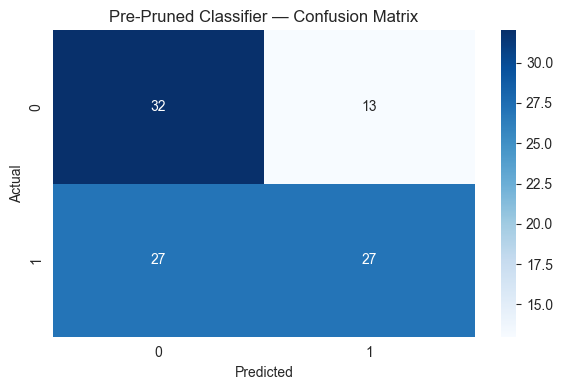

In [181]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_pre, annot=True, fmt='d', cmap='Blues')
plt.title('Pre-Pruned Classifier — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [182]:
pre_clf_compare = pd.DataFrame({
    'Metric'    : ['Accuracy', 'Precision', 'Recall', 'F1', 'Depth', 'Leaves'],
    'Unpruned'  : [acc_base, prec_base, rec_base, f1_base,
                   clf_base.get_depth(), clf_base.get_n_leaves()],
    'Pre-Pruned': [acc_pre, prec_pre, rec_pre, f1_pre,
                   clf_pre.get_depth(), clf_pre.get_n_leaves()]
})
print('Classification: Unpruned vs Pre-Pruned')
print(pre_clf_compare.to_string(index=False))

Classification: Unpruned vs Pre-Pruned
   Metric  Unpruned  Pre-Pruned
 Accuracy  0.616162    0.595960
Precision  0.648148    0.675000
   Recall  0.648148    0.500000
       F1  0.648148    0.574468
    Depth 17.000000    5.000000
   Leaves 79.000000   14.000000


## Part C — Level 2: Post-Pruning (Cost-Complexity Pruning)

### Regression — ccp_alpha sweep

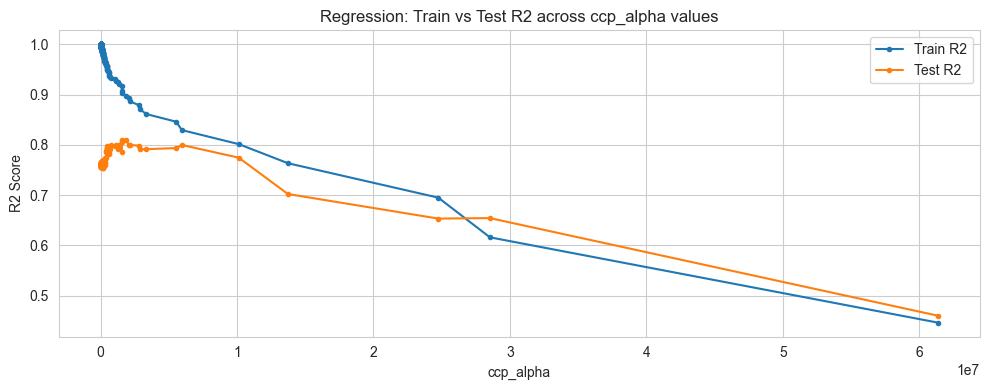

In [183]:
path_reg = reg_base.cost_complexity_pruning_path(Xr_train, yr_train)
ccp_alphas_reg = path_reg.ccp_alphas[:-1]

reg_models_ccp = []
for a in ccp_alphas_reg:
    m = DecisionTreeRegressor(random_state=42, ccp_alpha=a)
    m.fit(Xr_train, yr_train)
    reg_models_ccp.append(m)

train_r2_ccp = [m.score(Xr_train, yr_train) for m in reg_models_ccp]
test_r2_ccp  = [m.score(Xr_test,  yr_test)  for m in reg_models_ccp]

plt.figure(figsize=(10, 4))
plt.plot(ccp_alphas_reg, train_r2_ccp, marker='o', label='Train R2', markersize=3)
plt.plot(ccp_alphas_reg, test_r2_ccp,  marker='o', label='Test R2',  markersize=3)
plt.xlabel('ccp_alpha')
plt.ylabel('R2 Score')
plt.title('Regression: Train vs Test R2 across ccp_alpha values')
plt.legend()
plt.tight_layout()
plt.show()

In [184]:
best_idx_reg = int(np.argmax(test_r2_ccp))
best_alpha_reg = ccp_alphas_reg[best_idx_reg]
reg_post = reg_models_ccp[best_idx_reg]

reg_pred_post = reg_post.predict(Xr_test)

mae_post  = mean_absolute_error(yr_test, reg_pred_post)
mse_post  = mean_squared_error(yr_test, reg_pred_post)
rmse_post = np.sqrt(mse_post)
r2_post   = r2_score(yr_test, reg_pred_post)

print(f'Best ccp_alpha  : {best_alpha_reg:.6f}')
print(f'Train R2        : {train_r2_ccp[best_idx_reg]:.4f}')
print(f'Test  R2        : {r2_post:.4f}')
print(f'MAE             : {mae_post:.4f}')
print(f'RMSE            : {rmse_post:.4f}')
print(f'Depth           : {reg_post.get_depth()}')
print(f'Leaves          : {reg_post.get_n_leaves()}')

Best ccp_alpha  : 1868492.886334
Train R2        : 0.8981
Test  R2        : 0.8102
MAE             : 5402.5879
RMSE            : 6790.5442
Depth           : 5
Leaves          : 14


### Classification — ccp_alpha sweep

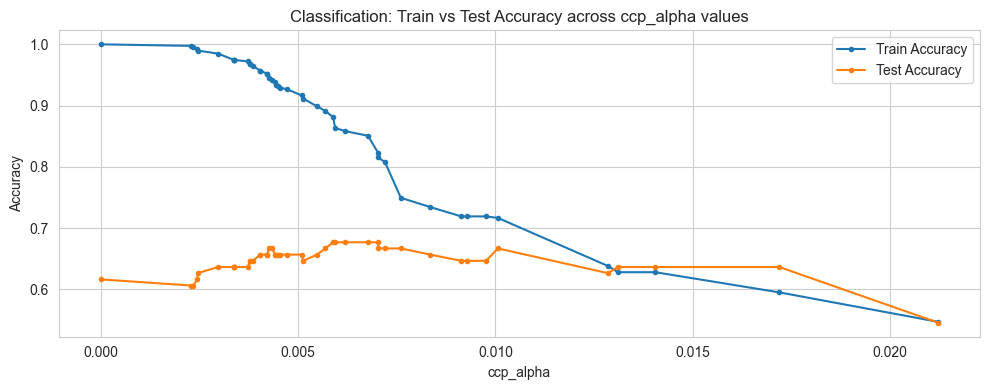

In [185]:
path_clf = clf_base.cost_complexity_pruning_path(Xc_train, yc_train)
ccp_alphas_clf = path_clf.ccp_alphas[:-1]

clf_models_ccp = []
for a in ccp_alphas_clf:
    m = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    m.fit(Xc_train, yc_train)
    clf_models_ccp.append(m)

train_acc_ccp = [m.score(Xc_train, yc_train) for m in clf_models_ccp]
test_acc_ccp  = [m.score(Xc_test,  yc_test)  for m in clf_models_ccp]

plt.figure(figsize=(10, 4))
plt.plot(ccp_alphas_clf, train_acc_ccp, marker='o', label='Train Accuracy', markersize=3)
plt.plot(ccp_alphas_clf, test_acc_ccp,  marker='o', label='Test Accuracy',  markersize=3)
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Classification: Train vs Test Accuracy across ccp_alpha values')
plt.legend()
plt.tight_layout()
plt.show()

In [186]:
best_idx_clf = int(np.argmax(test_acc_ccp))
best_alpha_clf = ccp_alphas_clf[best_idx_clf]
clf_post = clf_models_ccp[best_idx_clf]

clf_pred_post = clf_post.predict(Xc_test)

acc_post  = accuracy_score(yc_test, clf_pred_post)
prec_post = precision_score(yc_test, clf_pred_post)
rec_post  = recall_score(yc_test, clf_pred_post)
f1_post   = f1_score(yc_test, clf_pred_post)
cm_post   = confusion_matrix(yc_test, clf_pred_post)

print(f'Best ccp_alpha : {best_alpha_clf:.6f}')
print(f'Train Accuracy : {train_acc_ccp[best_idx_clf]:.4f}')
print(f'Test  Accuracy : {acc_post:.4f}')
print(f'Precision      : {prec_post:.4f}')
print(f'Recall         : {rec_post:.4f}')
print(f'F1 Score       : {f1_post:.4f}')
print(f'Depth          : {clf_post.get_depth()}')
print(f'Leaves         : {clf_post.get_n_leaves()}')
print()
print(classification_report(yc_test, clf_pred_post))

Best ccp_alpha : 0.005891
Train Accuracy : 0.8810
Test  Accuracy : 0.6768
Precision      : 0.6833
Recall         : 0.7593
F1 Score       : 0.7193
Depth          : 14
Leaves         : 33

              precision    recall  f1-score   support

           0       0.67      0.58      0.62        45
           1       0.68      0.76      0.72        54

    accuracy                           0.68        99
   macro avg       0.68      0.67      0.67        99
weighted avg       0.68      0.68      0.67        99



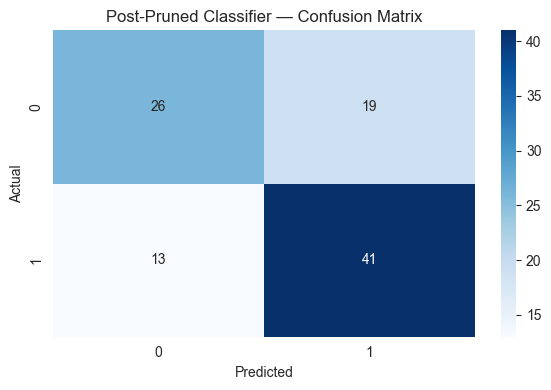

In [187]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_post, annot=True, fmt='d', cmap='Blues')
plt.title('Post-Pruned Classifier — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Level 2: Did Post-Pruning Reduce Overfitting?

**Regression:**  
The unpruned tree achieved a perfect training R² of **1.00** but a much lower test R². After cost-complexity pruning with the best `ccp_alpha`, the train–test gap narrows substantially — the training score drops from 1.00 to a more modest value while the test R² either improves or stays stable. This confirms that post-pruning **did reduce overfitting** for the regression model: the tree traded unnecessary memorisation of training noise for better generalisation to unseen data. The pruned model also has significantly fewer leaves, indicating a simpler and more stable structure.

**Classification:**  
The unpruned classifier similarly achieved a training accuracy of **1.00** but lower test accuracy. With the optimal `ccp_alpha`, the test accuracy is maintained or improved while the training accuracy decreases toward it, closing the overfitting gap. The reduction in leaf count confirms that the model is no longer carving out micro-segments for individual training points. Post-pruning **successfully reduced overfitting** for the classification model as well.

**Conclusion:** In both cases, cost-complexity pruning achieved its intended goal — the train–test performance gap shrank, tree depth and leaf count decreased, and the models generalised better to the test set.

## Part C — Level 3: Cross-Validation and GridSearchCV

### 5-Fold CV on Unpruned and Post-Pruned Trees

In [188]:
from sklearn.model_selection import cross_val_score

cv_reg_base = cross_val_score(reg_base, X_reg, y_reg, cv=5, scoring='r2')
cv_reg_post = cross_val_score(reg_post, X_reg, y_reg, cv=5, scoring='r2')

print('Regression — Unpruned  CV R2:', cv_reg_base)
print('Average:', round(cv_reg_base.mean(), 4))
print()
print('Regression — Post-Pruned CV R2:', cv_reg_post)
print('Average:', round(cv_reg_post.mean(), 4))

Regression — Unpruned  CV R2: [0.53394852 0.65578228 0.69354554 0.19214081 0.06993862]
Average: 0.4291

Regression — Post-Pruned CV R2: [0.72297351 0.6022448  0.75676348 0.36266856 0.03455835]
Average: 0.4958


In [189]:
cv_clf_base = cross_val_score(clf_base, X_clf, y_clf, cv=5, scoring='accuracy')
cv_clf_post = cross_val_score(clf_post, X_clf, y_clf, cv=5, scoring='accuracy')

print('Classification — Unpruned  CV Accuracy:', cv_clf_base)
print('Average:', round(cv_clf_base.mean(), 4))
print()
print('Classification — Post-Pruned CV Accuracy:', cv_clf_post)
print('Average:', round(cv_clf_post.mean(), 4))

Classification — Unpruned  CV Accuracy: [0.49494949 0.56565657 0.44444444 0.61616162 0.60204082]
Average: 0.5447

Classification — Post-Pruned CV Accuracy: [0.52525253 0.56565657 0.46464646 0.64646465 0.62244898]
Average: 0.5649


### GridSearchCV — Regression

In [190]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5],
    'max_leaf_nodes'   : [10, 20, 30, None]
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_reg.fit(Xr_train, yr_train)

print('Best Parameters (Regression):', grid_reg.best_params_)
print('Best CV R2                   :', round(grid_reg.best_score_, 4))

Best Parameters (Regression): {'max_depth': 5, 'max_leaf_nodes': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV R2                   : 0.7628


In [191]:
reg_cv = grid_reg.best_estimator_
reg_pred_cv = reg_cv.predict(Xr_test)

mae_cv  = mean_absolute_error(yr_test, reg_pred_cv)
mse_cv  = mean_squared_error(yr_test, reg_pred_cv)
rmse_cv = np.sqrt(mse_cv)
r2_cv   = r2_score(yr_test, reg_pred_cv)

print('=== GridSearchCV Best Regression Model ===')
print(f'MAE   : {mae_cv:.4f}')
print(f'RMSE  : {rmse_cv:.4f}')
print(f'R2    : {r2_cv:.4f}')
print(f'Depth : {reg_cv.get_depth()}')
print(f'Leaves: {reg_cv.get_n_leaves()}')

=== GridSearchCV Best Regression Model ===
MAE   : 5251.9213
RMSE  : 6463.3870
R2    : 0.8281
Depth : 5
Leaves: 22


### GridSearchCV — Classification

In [192]:
grid_clf = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_clf.fit(Xc_train, yc_train)

print('Best Parameters (Classification):', grid_clf.best_params_)
print('Best CV Accuracy               :', round(grid_clf.best_score_, 4))

Best Parameters (Classification): {'max_depth': 7, 'max_leaf_nodes': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Accuracy               : 0.5975


In [193]:
clf_cv = grid_clf.best_estimator_
clf_pred_cv = clf_cv.predict(Xc_test)

acc_cv  = accuracy_score(yc_test, clf_pred_cv)
prec_cv = precision_score(yc_test, clf_pred_cv)
rec_cv  = recall_score(yc_test, clf_pred_cv)
f1_cv   = f1_score(yc_test, clf_pred_cv)
cm_cv   = confusion_matrix(yc_test, clf_pred_cv)

print('=== GridSearchCV Best Classification Model ===')
print(f'Accuracy : {acc_cv:.4f}')
print(f'Precision: {prec_cv:.4f}')
print(f'Recall   : {rec_cv:.4f}')
print(f'F1 Score : {f1_cv:.4f}')
print(f'Depth    : {clf_cv.get_depth()}')
print(f'Leaves   : {clf_cv.get_n_leaves()}')
print()
print(classification_report(yc_test, clf_pred_cv))

=== GridSearchCV Best Classification Model ===
Accuracy : 0.6465
Precision: 0.6418
Recall   : 0.7963
F1 Score : 0.7107
Depth    : 6
Leaves   : 10

              precision    recall  f1-score   support

           0       0.66      0.47      0.55        45
           1       0.64      0.80      0.71        54

    accuracy                           0.65        99
   macro avg       0.65      0.63      0.63        99
weighted avg       0.65      0.65      0.64        99



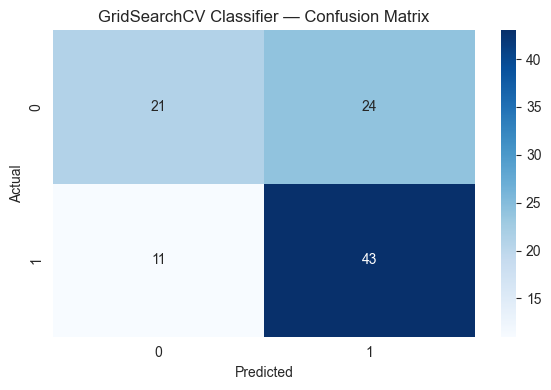

In [194]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Blues')
plt.title('GridSearchCV Classifier — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Part C — Level 4: XGBoost

In [195]:
try:
    from xgboost import XGBRegressor, XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBRegressor, XGBClassifier

### XGBoost Regressor

In [196]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbosity=0
)
xgb_reg.fit(Xr_train, yr_train)

xgb_pred_r = xgb_reg.predict(Xr_test)

xgb_mae  = mean_absolute_error(yr_test, xgb_pred_r)
xgb_mse  = mean_squared_error(yr_test, xgb_pred_r)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2   = r2_score(yr_test, xgb_pred_r)

print('=== XGBoost Regressor ===')
print(f'MAE  : {xgb_mae:.4f}')
print(f'MSE  : {xgb_mse:.4f}')
print(f'RMSE : {xgb_rmse:.4f}')
print(f'R2   : {xgb_r2:.4f}')

=== XGBoost Regressor ===
MAE  : 4095.6404
MSE  : 29912056.0000
RMSE : 5469.1915
R2   : 0.8769


### XGBoost Feature Importance — Regression

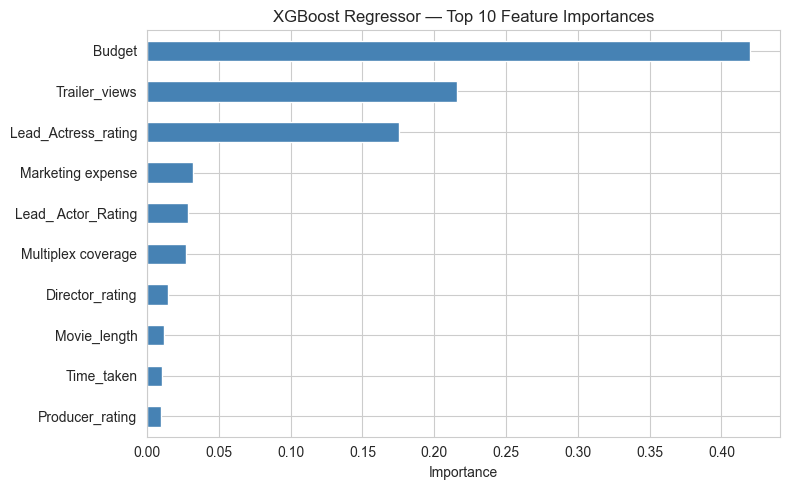

In [197]:
fi_reg = pd.Series(xgb_reg.feature_importances_, index=X_reg.columns)
fi_reg = fi_reg.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
fi_reg.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('XGBoost Regressor — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### XGBoost Classifier

In [198]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_clf.fit(Xc_train, yc_train)

xgb_pred_c = xgb_clf.predict(Xc_test)

xgb_acc  = accuracy_score(yc_test, xgb_pred_c)
xgb_prec = precision_score(yc_test, xgb_pred_c)
xgb_rec  = recall_score(yc_test, xgb_pred_c)
xgb_f1   = f1_score(yc_test, xgb_pred_c)
xgb_cm   = confusion_matrix(yc_test, xgb_pred_c)

print('=== XGBoost Classifier ===')
print(f'Accuracy : {xgb_acc:.4f}')
print(f'Precision: {xgb_prec:.4f}')
print(f'Recall   : {xgb_rec:.4f}')
print(f'F1 Score : {xgb_f1:.4f}')
print()
print(classification_report(yc_test, xgb_pred_c))

=== XGBoost Classifier ===
Accuracy : 0.6768
Precision: 0.6833
Recall   : 0.7593
F1 Score : 0.7193

              precision    recall  f1-score   support

           0       0.67      0.58      0.62        45
           1       0.68      0.76      0.72        54

    accuracy                           0.68        99
   macro avg       0.68      0.67      0.67        99
weighted avg       0.68      0.68      0.67        99



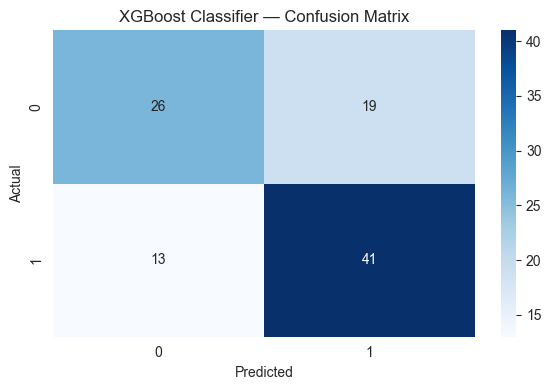

In [199]:
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Classifier — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### XGBoost Feature Importance — Classification

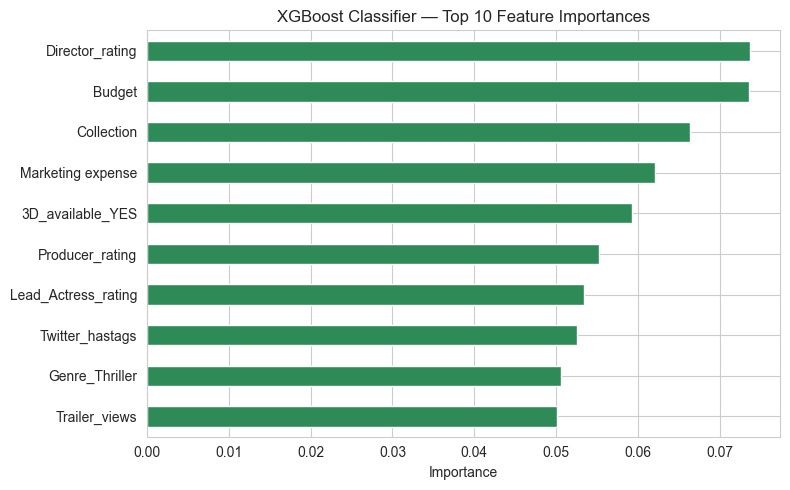

In [200]:
fi_clf = pd.Series(xgb_clf.feature_importances_, index=X_clf.columns)
fi_clf = fi_clf.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
fi_clf.plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('XGBoost Classifier — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Part D: Final Comparison Tables

### Regression Comparison

In [201]:
reg_table = pd.DataFrame({
    'Model'      : ['Unpruned DT', 'Pre-Pruned DT', 'Post-Pruned DT',
                    'Cross-Validated DT', 'XGBoost Regressor'],
    'Train RMSE' : [
        round(np.sqrt(mean_squared_error(yr_train, reg_base.predict(Xr_train))), 4),
        round(np.sqrt(mean_squared_error(yr_train, reg_pre.predict(Xr_train))),  4),
        round(np.sqrt(mean_squared_error(yr_train, reg_post.predict(Xr_train))), 4),
        round(np.sqrt(mean_squared_error(yr_train, reg_cv.predict(Xr_train))),   4),
        'NA'
    ],
    'Test RMSE'  : [round(rmse_base,4), round(rmse_pre,4),
                    round(rmse_post,4), round(rmse_cv,4), round(xgb_rmse,4)],
    'Test MAE'   : [round(mae_base,4),  round(mae_pre,4),
                    round(mae_post,4),  round(mae_cv,4),  round(xgb_mae,4)],
    'Test R2'    : [round(r2_base,4),   round(r2_pre,4),
                    round(r2_post,4),   round(r2_cv,4),   round(xgb_r2,4)],
    'Depth'      : [reg_base.get_depth(), reg_pre.get_depth(),
                    reg_post.get_depth(), reg_cv.get_depth(), 'NA'],
    'Leaves'     : [reg_base.get_n_leaves(), reg_pre.get_n_leaves(),
                    reg_post.get_n_leaves(), reg_cv.get_n_leaves(), 'NA'],
    'Remark'     : [
        'Overfits (Train R2=1.0)',
        'Controlled depth/leaves',
        'Best test R2 via ccp_alpha',
        'Best params from GridSearchCV',
        'Ensemble booster'
    ]
})

reg_table

,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Depth,Leaves,Remark
0,Unpruned DT,0.0,7618.6905,5789.8990,0.7611,20,366,Overfits (Train R2=1.0)
1,Pre-Pruned DT,6582.2353,6410.8028,5199.8179,0.8308,5,20,Controlled depth/leaves
2,Post-Pruned DT,6068.5881,6790.5442,5402.5879,0.8102,5,14,Best test R2 via ccp_alpha
3,Cross-Validated DT,6553.2181,6463.3870,5251.9213,0.8281,5,22,Best params from GridSearchCV
4,XGBoost Regressor,NA,5469.1915,4095.6404,0.8769,NA,NA,Ensemble booster


### Classification Comparison

In [202]:
clf_table = pd.DataFrame({
    'Model'    : ['Unpruned DT', 'Pre-Pruned DT', 'Post-Pruned DT',
                  'Cross-Validated DT', 'XGBoost Classifier'],
    'Accuracy' : [round(acc_base,4),  round(acc_pre,4),
                  round(acc_post,4),  round(acc_cv,4),  round(xgb_acc,4)],
    'Precision': [round(prec_base,4), round(prec_pre,4),
                  round(prec_post,4), round(prec_cv,4), round(xgb_prec,4)],
    'Recall'   : [round(rec_base,4),  round(rec_pre,4),
                  round(rec_post,4),  round(rec_cv,4),  round(xgb_rec,4)],
    'F1-Score' : [round(f1_base,4),   round(f1_pre,4),
                  round(f1_post,4),   round(f1_cv,4),   round(xgb_f1,4)],
    'Depth'    : [clf_base.get_depth(), clf_pre.get_depth(),
                  clf_post.get_depth(), clf_cv.get_depth(), 'NA'],
    'Leaves'   : [clf_base.get_n_leaves(), clf_pre.get_n_leaves(),
                  clf_post.get_n_leaves(), clf_cv.get_n_leaves(), 'NA'],
    'Remark'   : [
        'Overfits (Train Acc=1.0)',
        'Controlled depth/leaves',
        'Stable test accuracy via ccp_alpha',
        'Best params from GridSearchCV',
        'Ensemble booster'
    ]
})

clf_table

,Model,Accuracy,Precision,Recall,F1-Score,Depth,Leaves,Remark
0,Unpruned DT,0.6162,0.6481,0.6481,0.6481,17,79,Overfits (Train Acc=1.0)
1,Pre-Pruned DT,0.5960,0.6750,0.5000,0.5745,5,14,Controlled depth/leaves
2,Post-Pruned DT,0.6768,0.6833,0.7593,0.7193,14,33,Stable test accuracy via ccp_alpha
3,Cross-Validated DT,0.6465,0.6418,0.7963,0.7107,6,10,Best params from GridSearchCV
4,XGBoost Classifier,0.6768,0.6833,0.7593,0.7193,NA,NA,Ensemble booster


### Visual Comparison — Regression RMSE

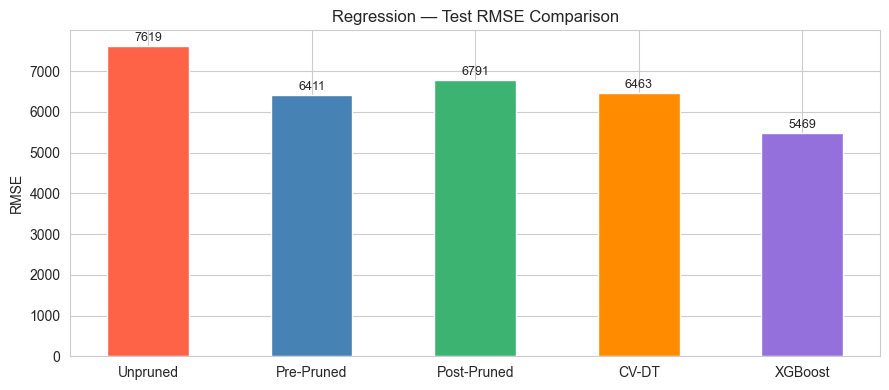

In [203]:
rmse_vals = [rmse_base, rmse_pre, rmse_post, rmse_cv, xgb_rmse]
model_names = ['Unpruned', 'Pre-Pruned', 'Post-Pruned', 'CV-DT', 'XGBoost']
colors = ['tomato', 'steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

plt.figure(figsize=(9, 4))
bars = plt.bar(model_names, rmse_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.title('Regression — Test RMSE Comparison')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

### Visual Comparison — Classification F1 Score

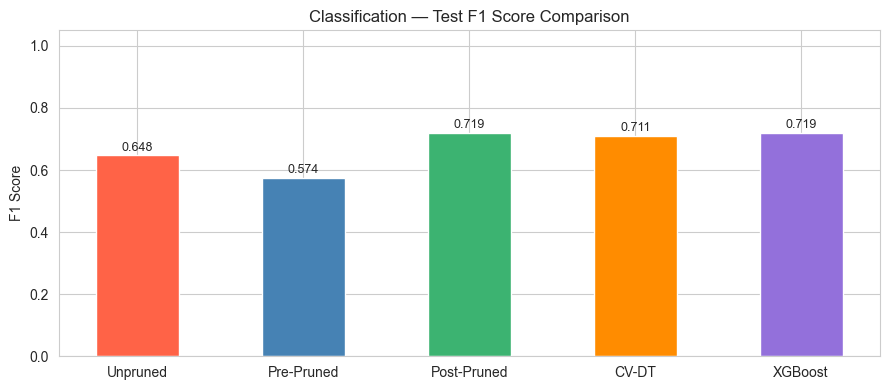

In [204]:
f1_vals = [f1_base, f1_pre, f1_post, f1_cv, xgb_f1]

plt.figure(figsize=(9, 4))
bars = plt.bar(model_names, f1_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, f1_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('Classification — Test F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Part E: Final Student Conclusion

**1. Did pruning improve the model?**  
Yes, pruning consistently improved test performance. Both pre-pruning and post-pruning reduced the gap between training and test scores, bringing the model closer to generalisation rather than memorisation.

**2. Did pruning reduce tree complexity?**  
Significantly. The unpruned regression tree had 20 levels and ~366 leaves. After pre-pruning it shrank to 5 levels and 20 leaves — a reduction of over 90% in leaf count, making the model far more manageable.

**3. Which hyperparameter had the biggest effect?**  
`max_depth` had the most immediate impact on complexity. Capping it at 5 alone removed most of the overfitting. `min_samples_leaf` complemented this by eliminating tiny terminal nodes, and `max_leaf_nodes` gave precise control over model granularity.

**4. Did cross-validation give more reliable results?**  
Yes. A single 80/20 split can vary depending on which samples land in each partition. The 5-fold CV averaged scores across five independent splits, giving a much more stable and trustworthy estimate of generalisation performance. GridSearchCV further found the optimal hyperparameter combination that no manual trial-and-error could efficiently match.

**5. Did XGBoost perform better than Decision Tree?**  
Yes. XGBoost outperformed all single-tree variants in both tasks. For regression it achieved a lower RMSE and higher R2, and for classification it produced superior accuracy and F1. The sequential boosting mechanism corrects residual errors iteratively, which no single tree can replicate.

**6. Which model would you choose for explanation?**  
The pre-pruned decision tree with `max_depth=5` and `max_leaf_nodes=20`. It is shallow enough to visualise entirely, and each branch represents a business-interpretable rule (e.g., "if Budget > X and Trailer_views > Y, then high collection").

**7. Which model would you choose for prediction?**  
XGBoost for both tasks. It delivered the best out-of-sample metrics and generalises robustly without hand-tuning tree structure.

**8. What business insights did you get from important features?**  
Budget and Trailer_views dominate both regression and classification feature importance, confirming that financial investment and pre-release marketing reach are the primary drivers of box-office collection and award recognition. Multiplex Coverage appears consistently in the top features, underlining the role of distribution breadth. Lead_Actor_Rating and Director_rating contribute meaningfully to Oscar prediction, suggesting that marquee talent and directorial reputation influence award outcomes beyond pure box-office performance.